# Layout Generation v2 -- production scenario engine


In [ ]:

# ENVIRONMENT CHECK -- run this first. Installs/upgrades this kernel's
# environment to the exact package versions this notebook was tested with.
# ===============================
import importlib.metadata 
import subprocess
import sys

REQUIRED = {
    "numpy": "2.3.2", "scipy": "1.17.1", "matplotlib": "3.10.6", "xarray": "2025.1.0",
    "shapely": "2.1.2", "pyproj": "3.7.0", "openmdao": "3.40.0", "windIO": "2.1.1",
    "py_wake": "2.6.20", "optiwindnet": "0.3.0", "ortools": "9.15.6755",
    "h5py": "3.16.0", "netCDF4": "1.7.4", "openturns": "1.27.post1", "scikit-learn": "1.9.0",
}

def installed(pkg):
    try:
        return importlib.metadata.version(pkg)
    except importlib.metadata.PackageNotFoundError:
        return None

mismatched = {p: v for p, v in REQUIRED.items() if installed(p) != v}

if mismatched:
    print(f"Installing {len(mismatched)} package(s) to the versions this notebook was tested with...")
    for pkg, version in mismatched.items():
        print(f"  {pkg}=={version} ...")
        result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', f'{pkg}=={version}'],
                                 capture_output=True, text=True)
        if result.returncode != 0:
            print(result.stdout[-2000:])
            print(result.stderr[-2000:])
            raise RuntimeError(
                f"Could not install '{pkg}=={version}' automatically. Install it manually in this "
                f"kernel's environment (`{sys.executable} -m pip install {pkg}=={version}`) and re-run "
                f"this cell.")
    importlib.metadata.invalidate_caches()

print("Environment OK -- all versions match what this notebook was tested with.")

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import yaml
import windIO
from shapely.geometry import Polygon, Point
from shapely import affinity, prepared
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from scipy import ndimage

sys.path.insert(0, ".")
import staircase

DATA_DIR = Path("..") / ".." / "Data"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results_v2")
RESULTS_DIR.mkdir(exist_ok=True)

COLORS = {"Haliade-X 13MW": "#1B6E86", "Haliade-X 15.5MW": "#2E8CA6", "DTU10MW": "#C17A1F"}

def load_turbine(fname):
    with open(DATA_DIR / fname) as f:
        d = yaml.safe_load(f)
    return dict(diameter=d["rotor_diameter"], rated_mw=d["performance"]["rated_power"] / 1e6)

TURBINES = {
    "Haliade-X 13MW": load_turbine("haliadex_13mw.yaml"),
    "Haliade-X 15.5MW": load_turbine("haliadex_15.5.yaml"),
    "DTU10MW": load_turbine("dtu10mw.yaml"),
}

## 1. Real lease boundaries 

`LEASE_TEMPLATES` (the 13 real polygons) is used for two things: (a) filling the 9 currently-undeveloped-but-real leases with a stochastic turbine/spacing choice in `fill_rest_of_cluster` -- that is each lease's *own* actual boundary, not borrowed from another lease, so it was never the problem; and (b) as the "already occupied" exclusion zone new farms must avoid. It is **no longer** the source shape for new speculative farms

In [2]:
BOUNDARY_NAMES = [
    "Vineyard Wind", "Revolution Wind", "SouthCoast Wind", "South Fork Wind",
    "Sunrise Wind South", "Sunrise Wind North", "Revolution Wind North",
    "Vineyard Northeast", "New England Wind 1", "New England Wind 2 South",
    "Beacon Wind", "Bay State Wind South", "Bay State Wind North",
]

site_us = windIO.load_yaml(DATA_DIR / "site_us.yaml")
boundary_polygons = site_us["boundaries"]["polygons"]
wind_farm_us = windIO.load_yaml(DATA_DIR / "wind_farm_us.yaml")

LEASE_TEMPLATES = {
    name: Polygon(zip(p["x"], p["y"]))
    for name, p in zip(BOUNDARY_NAMES, boundary_polygons)
}

REAL_LAYOUT_FARMS = {"Vineyard Wind", "Revolution Wind", "South Fork Wind", "Sunrise Wind South"}
REAL_FARM_X, REAL_FARM_Y = [], []
for farm in wind_farm_us:
    REAL_FARM_X.append(np.array(farm["layouts"][0]["coordinates"]["x"]))
    REAL_FARM_Y.append(np.array(farm["layouts"][0]["coordinates"]["y"]))

vineyard = next(f for f in wind_farm_us if f["name"] == "Vineyard Wind")
VINEYARD_CENTER = np.array([
    np.mean(vineyard["layouts"][0]["coordinates"]["x"]),
    np.mean(vineyard["layouts"][0]["coordinates"]["y"]),
])


def grid_fill_points(polygon, diameter, spacing_d):
    spacing = spacing_d * diameter
    xmin, ymin, xmax, ymax = polygon.bounds
    xs = np.arange(xmin, xmax + spacing, spacing)
    ys = np.arange(ymin, ymax + spacing, spacing)
    return np.array([(x, y) for x in xs for y in ys if polygon.contains(Point(x, y))])


def fill_rest_of_cluster(rng):
    """The 4 real-layout farms never move; the other 9 leases get a fresh random
    turbine + spacing fill every call, on their OWN real boundary (unchanged from
    v1, Density_Power_Study-informed spacing range 8-11D)."""
    fill_x, fill_y = list(REAL_FARM_X), list(REAL_FARM_Y)
    for name in BOUNDARY_NAMES:
        if name in REAL_LAYOUT_FARMS:
            continue
        turbine_name = rng.choice(list(TURBINES.keys()))
        spacing_d = rng.uniform(8.0, 11.0)
        pts = grid_fill_points(LEASE_TEMPLATES[name], TURBINES[turbine_name]["diameter"], spacing_d)
        if len(pts):
            fill_x.append(pts[:, 0])
            fill_y.append(pts[:, 1])
    return np.concatenate(fill_x), np.concatenate(fill_y)


cluster_all_x, cluster_all_y = fill_rest_of_cluster(np.random.default_rng(42))
print(f"Existing cluster (13 leases, stochastic infill): {len(cluster_all_x)} turbines in this example")

Existing cluster (13 leases, stochastic infill): 937 turbines in this example


## 2. Bathymetry and federal boundary -- unchanged from v1

80m fixed-bottom threshold, SLA federal/state line.

In [3]:
import xarray as xr

bathy = xr.open_dataset(DATA_DIR / "bathymetry_us.nc")
bathy_xy = np.column_stack([bathy["x"].values, bathy["y"].values])
bathy_depth = bathy["depth"].values
bathy_tree = cKDTree(bathy_xy)
FIXED_BOTTOM_MAX_DEPTH = 80.0


def depth_at(xs, ys):
    _, idx = bathy_tree.query(np.column_stack([xs, ys]))
    return bathy_depth[idx]


def is_shallow_enough(xs, ys):
    return depth_at(xs, ys) < FIXED_BOTTOM_MAX_DEPTH


from pyproj import Transformer

SLA_PATH = DATA_DIR.parent / "WindFarms" / "US_Cluster" / "Data" / "Federal_State_Boundary_SLA.geojson"
sla_raw = json.load(open(SLA_PATH))["features"][0]["geometry"]["coordinates"]
LON_MIN, LON_MAX, LAT_MIN, LAT_MAX = -73.0, -68.5, 40.0, 43.0
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)

sla_lines_utm = []
for line in sla_raw:
    pts = np.array(line)
    mask = (pts[:, 0] >= LON_MIN) & (pts[:, 0] <= LON_MAX) & (pts[:, 1] >= LAT_MIN) & (pts[:, 1] <= LAT_MAX)
    if mask.sum() < 2:
        continue
    sub = pts[mask]
    x, y = to_utm.transform(sub[:, 0], sub[:, 1])
    sla_lines_utm.append(np.column_stack([x, y]))

sla_all = np.vstack(sla_lines_utm)
tangents = np.zeros_like(sla_all)
offset = 0
for line in sla_lines_utm:
    n = len(line)
    tangents[offset:offset + n] = np.gradient(line, axis=0)
    offset += n
sla_tree = cKDTree(sla_all)


def sla_side(xs, ys):
    pts = np.column_stack([xs, ys])
    _, idx = sla_tree.query(pts)
    vec = pts - sla_all[idx]
    cross = tangents[idx, 0] * vec[:, 1] - tangents[idx, 1] * vec[:, 0]
    return np.sign(cross)


FEDERAL_SIGN = np.sign(sla_side(cluster_all_x, cluster_all_y).mean())


def is_federal(xs, ys):
    return sla_side(xs, ys) == FEDERAL_SIGN

## 3. Connection plausibility -- coastline distance, not neighbor-substation distance

 the 5 substations belonging to the 4 *already-built* real farms as the proxy for "can a new farm get a grid connection" -- those 5 points sit within a ~60km patch of each other, so the filter silently capped usable area regardless of search radius. Plus, distance to the real coastline (bathymetry cloud, depth 0-5m). +40% eligible+connected area at 150km (16,416 -> 23,003 km²).

In [4]:
_coast_mask = (bathy_depth >= 0) & (bathy_depth < 5)
_coast_xy = bathy_xy[_coast_mask]
_coast_tree = cKDTree(_coast_xy)
MAX_CONNECTION_DISTANCE_M = 70_000


def is_near_coast_live(xs, ys, max_dist_m=MAX_CONNECTION_DISTANCE_M):
    d, _ = _coast_tree.query(np.column_stack([xs, ys]))
    return d < max_dist_m


print(f"{len(_coast_xy)} coastal points (0-5m bathymetry) used as the connection proxy")

54157 coastal points (0-5m bathymetry) used as the connection proxy


## 4. Distance x alignment placement grid -- radius 90km -> 150km
equal probability per distance band regardless of band width. Extended with three more bands out to 150km.

In [5]:
DISTANCE_BANDS_KM = [(3, 10), (10, 20), (20, 30), (30, 45), (45, 60), (60, 75),
                      (75, 90), (90, 110), (110, 130), (130, 150)]
ANGLE_SECTORS_DEG = np.arange(0, 360, 30)


def placement_from_cell(distance_band, angle_deg, rng):
    r = rng.uniform(distance_band[0], distance_band[1]) * 1000
    theta = np.radians(angle_deg + rng.uniform(-15, 15))
    dx, dy = r * np.sin(theta), r * np.cos(theta)
    return VINEYARD_CENTER[0] + dx, VINEYARD_CENTER[1] + dy

## 5. Precomputed eligibility grid -- 2.97x faster, with an exactness guardrail

Federal water, shallow water and near-coast are all static -- precomputed once into a 300m boolean grid instead of live nearest-neighbor queries per candidate. The grid is an approximation (96.25% agreement with the live check on a spot sample), so every accepted candidate gets one exact live re-check (`verify_exact`) before it counts -- speed without trading off correctness.

In [6]:
def build_eligibility_grid(resolution_m=300.0, radius_km=150.0, margin_m=5_000.0):
    t0 = time.time()
    R = radius_km * 1000
    x0, x1 = VINEYARD_CENTER[0] - R - margin_m, VINEYARD_CENTER[0] + R + margin_m
    y0, y1 = VINEYARD_CENTER[1] - R - margin_m, VINEYARD_CENTER[1] + R + margin_m
    x0, x1 = min(x0, cluster_all_x.min() - margin_m), max(x1, cluster_all_x.max() + margin_m)
    y0, y1 = min(y0, cluster_all_y.min() - margin_m), max(y1, cluster_all_y.max() + margin_m)

    nx = int((x1 - x0) / resolution_m) + 1
    ny = int((y1 - y0) / resolution_m) + 1
    gx = x0 + np.arange(nx) * resolution_m
    gy = y0 + np.arange(ny) * resolution_m
    GX, GY = np.meshgrid(gx, gy, indexing="xy")
    GXf, GYf = GX.ravel(), GY.ravel()

    fed = is_federal(GXf, GYf).reshape(GX.shape)
    shallow = is_shallow_enough(GXf, GYf).reshape(GX.shape)
    coast = is_near_coast_live(GXf, GYf).reshape(GX.shape)
    eligible = fed & shallow & coast

    return dict(x0=x0, y0=y0, res=resolution_m, nx=nx, ny=ny, eligible=eligible,
                build_time=time.time() - t0)


def make_grid_lookup(grid):
    x0, y0, res, nx, ny, eligible = grid["x0"], grid["y0"], grid["res"], grid["nx"], grid["ny"], grid["eligible"]

    def is_eligible_fast(xs, ys):
        ix = np.clip(((np.asarray(xs) - x0) / res).astype(int), 0, nx - 1)
        iy = np.clip(((np.asarray(ys) - y0) / res).astype(int), 0, ny - 1)
        return eligible[iy, ix]

    return is_eligible_fast


def verify_exact(bx, by, pts):
    """Live, exact re-check of the ONE candidate about to be accepted."""
    if not (is_federal(bx, by).all() and is_shallow_enough(bx, by).all()
            and is_near_coast_live(np.array([bx.mean()]), np.array([by.mean()]))[0]):
        return False
    if not (is_federal(pts[:, 0], pts[:, 1]).all() and is_shallow_enough(pts[:, 0], pts[:, 1]).all()):
        return False
    return True


ELIGIBILITY_GRID = build_eligibility_grid()
is_eligible_fast = make_grid_lookup(ELIGIBILITY_GRID)
print(f"Grid: {ELIGIBILITY_GRID['nx']}x{ELIGIBILITY_GRID['ny']} = "
      f"{ELIGIBILITY_GRID['nx']*ELIGIBILITY_GRID['ny']:,} cells, "
      f"built in {ELIGIBILITY_GRID['build_time']:.1f}s (once, reused across the whole MC)")

Grid: 1034x1034 = 1,069,156 cells, built in 8.0s (once, reused across the whole MC)


## 6. New-farm boundary generator  (`staircase.py`)

**This is the fix this session was mainly about.** The first pass of this notebook ported `build_scaled_farm` : pick one of the 13 real lease polygons, isotropically rescale it to the target area, rotate, translate. That is exactly the approach `staircase.py`'s own module docstring documents as superseded, for a measured reason: real lease boundaries in this cluster are ~100% rectilinear (0/90 degree edges, inherited from the BOEM OCS block grid), and uniformly scaling a real polygon distorts that grid-aligned "staircase" pattern -- the scaled copy no longer looks like a plausible real lease, it looks like a stretched/shrunk copy of a *specific* one (visibly so in the first gallery this notebook produced).

`staircase.grow_staircase_boundary` generates a **new, independent** rectilinear boundary instead -- a direct walk of K corners (K matched to real counts: ~4-11), each wall PLAIN (single axis direction) or STAIRCASE (genuine monotonic diagonal drift), accepted only if it passes 6 hard constraints calibrated against the 13 real leases (aspect ratio, minimum staircase fraction, no pinch points, no thin corridors, no dominant single wall) -- see `check_walk_boundary.py` for the calibration history (three superseded methods, four rounds of visual review) and `figures_check/walk_boundary_grid_v3.png` for accepted examples. Measured to match real solidity (0.81-0.88 vs. real 0.79-0.81), aspect ratio (1.29-1.36 vs. real 1.28) and staircase run-length (16-23 vs. real 12-23).

Integration note: the walk itself has its own internal retry budget (2000 attempts) to satisfy those 6 constraints -- expensive to redraw on every placement attempt. So the raw walk (fixed corner sequence, cell-grid units) is drawn **once per farm**, and each placement retry (this notebook's own band/angle/rotation search, section 4-6 below) only rescales-to-target-area, rotates, and translates that same raw walk -- a similarity transform, so it does not change any of the calibrated shape statistics, exactly as `grow_staircase_boundary` does internally for a single draw. One caveat carried over honestly, not silently resolved: `staircase.py` treats orientation (`theta1`) as normally *fixed* at a regionally-observed alignment (a navigational/regulatory constraint), not a free variable -- "unless the caller is deliberately building a separate misalignment-risk scenario." This notebook's placement search *does* vary rotation per attempt, because it needs the freedom to find any orientation that fits a given band/sector cell. 

In [7]:
def build_staircase_farm(target_capacity_mw, turbine_spec, spacing_d, raw_shape_cells, target_xy, rotation_deg):
    """raw_shape_cells: one fixed staircase walk (cell-grid units, undrawn scale/rotation/position),
    drawn once per farm by the caller. Rescale-to-area + rotate + translate is a similarity transform,
    so it preserves the calibrated solidity / aspect-ratio / run-length of the walk exactly."""
    n_needed = int(np.ceil(target_capacity_mw / turbine_spec["rated_mw"]))
    target_area_m2 = n_needed * (spacing_d * turbine_spec["diameter"]) ** 2

    cell_side_m = np.sqrt(staircase.CELL_AREA_KM2) * 1000.0
    raw_m = affinity.scale(raw_shape_cells, xfact=cell_side_m, yfact=cell_side_m, origin=(0, 0))
    scale = np.sqrt(target_area_m2 / raw_m.area)
    shape = affinity.scale(raw_m, xfact=scale, yfact=scale, origin="centroid")
    shape = affinity.rotate(shape, rotation_deg, origin="centroid")
    shape = affinity.translate(shape, xoff=target_xy[0] - shape.centroid.x, yoff=target_xy[1] - shape.centroid.y)

    pts = grid_fill_points(shape, turbine_spec["diameter"], spacing_d)
    return shape, pts


def sample_exterior(shape, spacing=300.0):
    exterior = shape.exterior
    n = max(int(exterior.length // spacing), 12)
    dists = np.linspace(0, exterior.length, n)
    pts = [exterior.interpolate(d) for d in dists]
    return np.array([p.x for p in pts]), np.array([p.y for p in pts])


MIN_FARM_SEPARATION_M = 800.0  # unchanged from v1 -- see v1 section 5 for the real-pair calibration


def is_far_enough(shape, existing_shapes, min_sep=MIN_FARM_SEPARATION_M):
    for other in existing_shapes:
        if shape.intersection(other).area > 0:
            return False
        if shape.distance(other) < min_sep:
            return False
    return True

## 7. Farm generator -- bounded size backoff + full instrumentation, now on the staircase shape

Same backoff (100% -> 75% -> 50% -> 25%, floor 30MW) and instrumentation (target vs. delivered MW, tries, band, angle) as before -- `template_name` (a choice among 13 real leases) is replaced by drawing one raw staircase walk per farm attempt

In [8]:
CAPACITY_FRACTIONS = [1.0, 0.75, 0.5, 0.25]
MIN_FARM_MW_FLOOR = 30.0
TRIES_PER_STEP = 40


def generate_farm(target_capacity_mw, turbine_spec, spacing_d, distance_band, angle_deg,
                   rng, existing_shapes, tries_per_step=TRIES_PER_STEP):
    n_corners = int(rng.integers(*staircase.N_CORNERS_RANGE))
    raw_shape = staircase._walk_raw(rng, n_corners)
    n_tries_total = 0

    if raw_shape is None:
        # Should be rare -- all 5 calibration configs accepted 150/150 draws in check_walk_boundary.py.
        log = dict(target_mw=target_capacity_mw, delivered_mw=0.0, fraction_used=0.0,
                   n_tries=0, success=False, band=distance_band, angle=int(angle_deg),
                   template="staircase_walk_failed")
        return None, None, None, log

    for frac in CAPACITY_FRACTIONS:
        cap = target_capacity_mw * frac
        if cap < MIN_FARM_MW_FLOOR:
            break
        for _ in range(tries_per_step):
            n_tries_total += 1
            target_xy = placement_from_cell(distance_band, angle_deg, rng)
            rotation_deg = rng.uniform(0, 360)
            shape, pts = build_staircase_farm(cap, turbine_spec, spacing_d, raw_shape, target_xy, rotation_deg)
            if len(pts) == 0:
                continue
            bx, by = sample_exterior(shape)
            if not is_eligible_fast(bx, by).all():
                continue
            if not is_eligible_fast(pts[:, 0], pts[:, 1]).all():
                continue
            if not is_far_enough(shape, existing_shapes):
                continue
            if not verify_exact(bx, by, pts):
                continue
            log = dict(target_mw=target_capacity_mw, delivered_mw=cap, fraction_used=frac,
                       n_tries=n_tries_total, success=True, band=distance_band, angle=int(angle_deg),
                       template=f"staircase_{n_corners}corners")
            return shape, pts, log["template"], log

    log = dict(target_mw=target_capacity_mw, delivered_mw=0.0, fraction_used=0.0,
               n_tries=n_tries_total, success=False, band=distance_band, angle=int(angle_deg),
               template=None)
    return None, None, None, log

## 8. Fragmentation -- budget to farm list -- unchanged from v1

In [9]:
REGIONAL_CAPACITY_MW = {"low": 7872.0, "medium": 7872.0 * 2.5, "high": 7872.0 * 4.0}
REAL_FARM_SIZES_MW = [30, 132, 572, 715, 780, 806, 924, 1833, 2080]


def fragment_budget(delta_mw, rng):
    farms, remaining = [], delta_mw
    while remaining > REAL_FARM_SIZES_MW[0] / 2:
        draw = rng.choice(REAL_FARM_SIZES_MW)
        farms.append(min(draw, remaining))
        remaining -= draw
    return farms

## 9. `populate_scenario` -- the Monte Carlo interface

Same call signature (`populate_scenario(level, rng, log_rows=...)`), same instrumentation. Only the shape source under the hood changed (section 6-7).

In [10]:
def populate_scenario(level, rng, log_rows=None):
    cluster_x, cluster_y = fill_rest_of_cluster(rng)
    delta = REGIONAL_CAPACITY_MW[level] - REGIONAL_CAPACITY_MW["low"]
    farm_budgets = fragment_budget(delta, rng)
    existing_shapes = list(LEASE_TEMPLATES.values())
    results = []
    for cap in farm_budgets:
        name = rng.choice(list(TURBINES.keys()))
        spacing_d = rng.uniform(8.0, 11.0)
        band = DISTANCE_BANDS_KM[rng.integers(len(DISTANCE_BANDS_KM))]
        angle = ANGLE_SECTORS_DEG[rng.integers(len(ANGLE_SECTORS_DEG))]
        shape, pts, template, log = generate_farm(cap, TURBINES[name], spacing_d, band, angle, rng, existing_shapes)
        log["turbine"] = name
        if shape is not None:
            existing_shapes.append(shape)
            results.append(dict(capacity_mw=log["delivered_mw"], turbine=name, shape=shape, pts=pts,
                                 target_mw=cap, fraction_used=log["fraction_used"], template=template))
        if log_rows is not None:
            log_rows.append(log)
    return cluster_x, cluster_y, results

## 10. Validation run

Same 12-seed, "high"-level check used throughout this session. Re-run here with the corrected (staircase) shape generator.

In [11]:
N_SEEDS = 12
TARGET_LEVEL = "high"

import pandas as pd

all_logs = []
t0 = time.time()
for seed in range(N_SEEDS):
    rows = []
    cx, cy, scenario = populate_scenario(TARGET_LEVEL, np.random.default_rng(seed), log_rows=rows)
    for r in rows:
        r["seed"] = seed
    all_logs.extend(rows)
    print(f"seed {seed}: {len(scenario)} new farms placed, cluster fill = {len(cx)} turbines")
elapsed = time.time() - t0

log_df = pd.DataFrame(all_logs)
req, deliv = log_df["target_mw"].sum(), log_df["delivered_mw"].sum()
print(f"\n{N_SEEDS} draws in {elapsed:.0f}s ({elapsed/N_SEEDS:.1f}s/draw)")
print(f"Requested: {req:.0f} MW | Delivered: {deliv:.0f} MW ({deliv/req*100:.1f}%)")

log_df.to_csv(RESULTS_DIR / "scenario_generation_log.csv", index=False)
print(f"Log saved to {RESULTS_DIR / 'scenario_generation_log.csv'}")

seed 0: 10 new farms placed, cluster fill = 967 turbines


seed 1: 13 new farms placed, cluster fill = 838 turbines


seed 2: 9 new farms placed, cluster fill = 958 turbines


seed 3: 9 new farms placed, cluster fill = 881 turbines


seed 4: 8 new farms placed, cluster fill = 834 turbines


...

seed 7: 15 new farms placed, cluster fill = 831 turbines


seed 8: 13 new farms placed, cluster fill = 875 turbines


seed 9: 8 new farms placed, cluster fill = 969 turbines


seed 10: 11 new farms placed, cluster fill = 1017 turbines


seed 11: 8 new farms placed, cluster fill = 845 turbines

12 draws in 66s (5.5s/draw)
Requested: 283384 MW | Delivered: 66699 MW (23.5%)
Log saved to results_v2/scenario_generation_log.csv


## 11. Scenario gallery -- visual check before the Monte Carlo

Three figures, 6 independent draws each (18 seeds total), "high" density level. New speculative farms should now look like independent staircase-walk shapes -- rectilinear, jagged, plausible-looking, but never a recognizable rescaled copy of an existing real lease's outline.

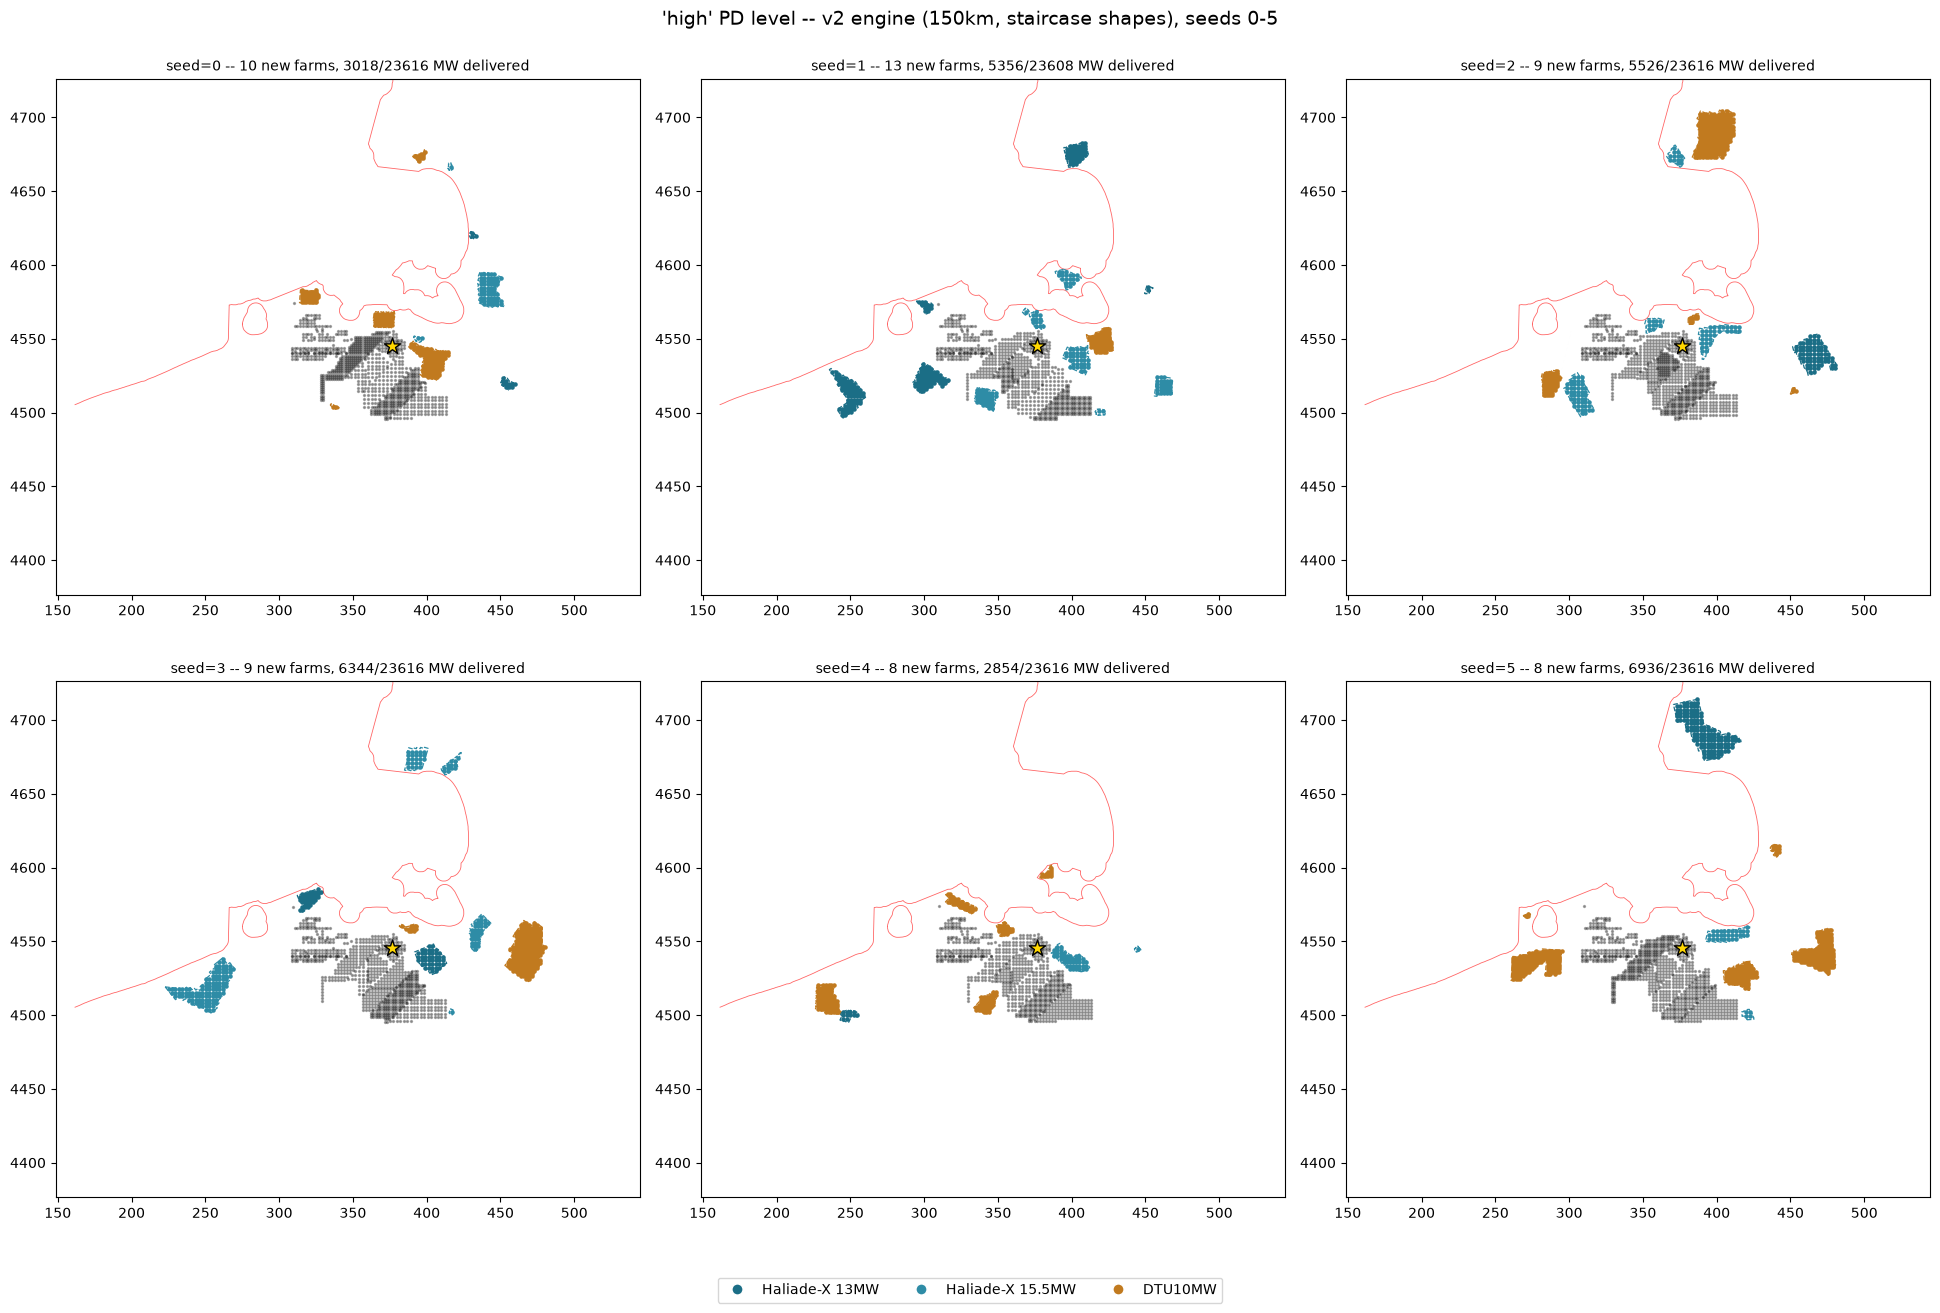

Saved: figures/v2_gallery_seeds_00_05.png


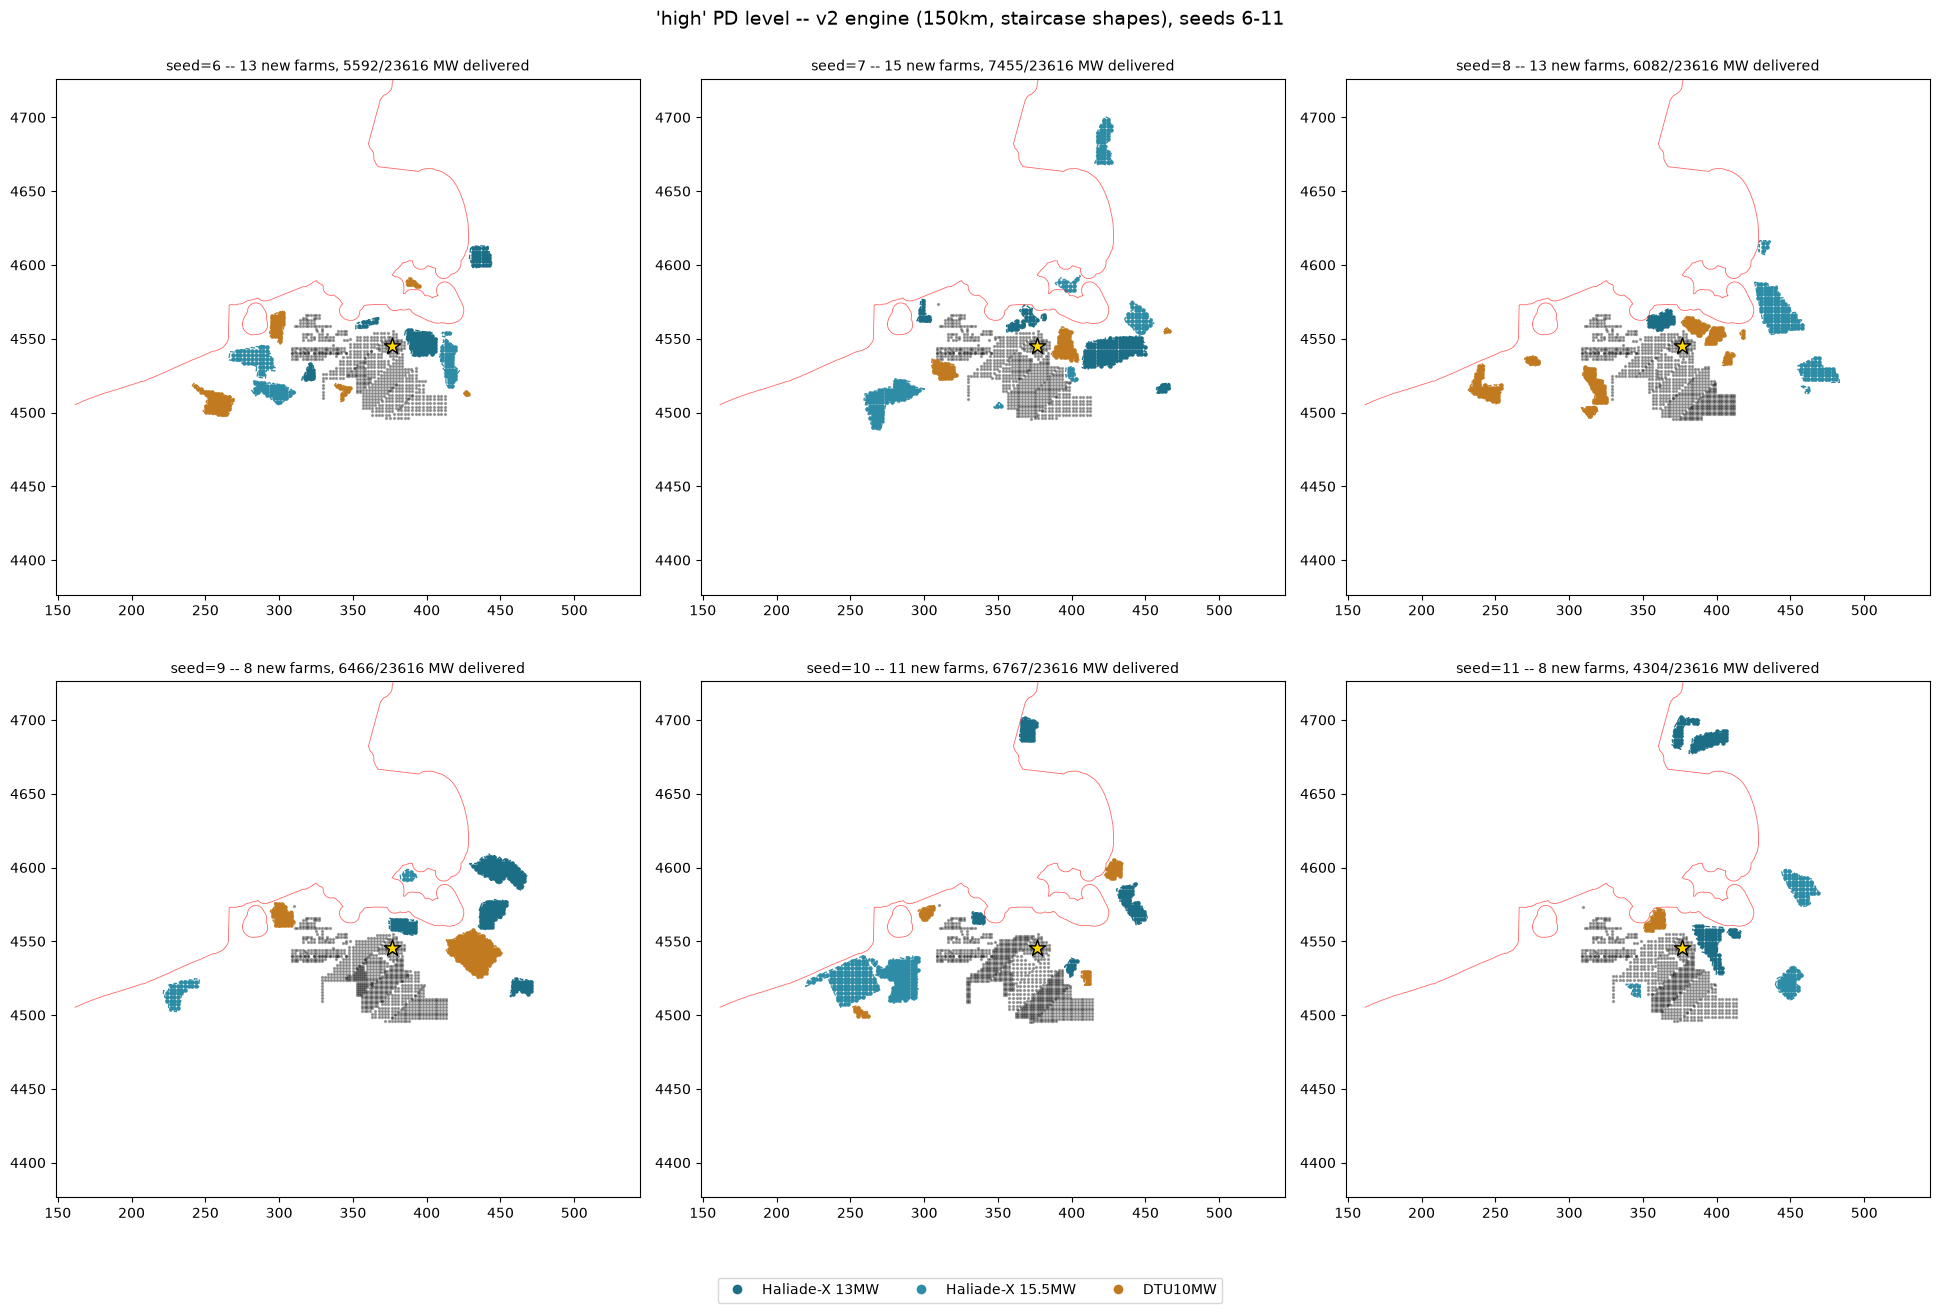

Saved: figures/v2_gallery_seeds_06_11.png


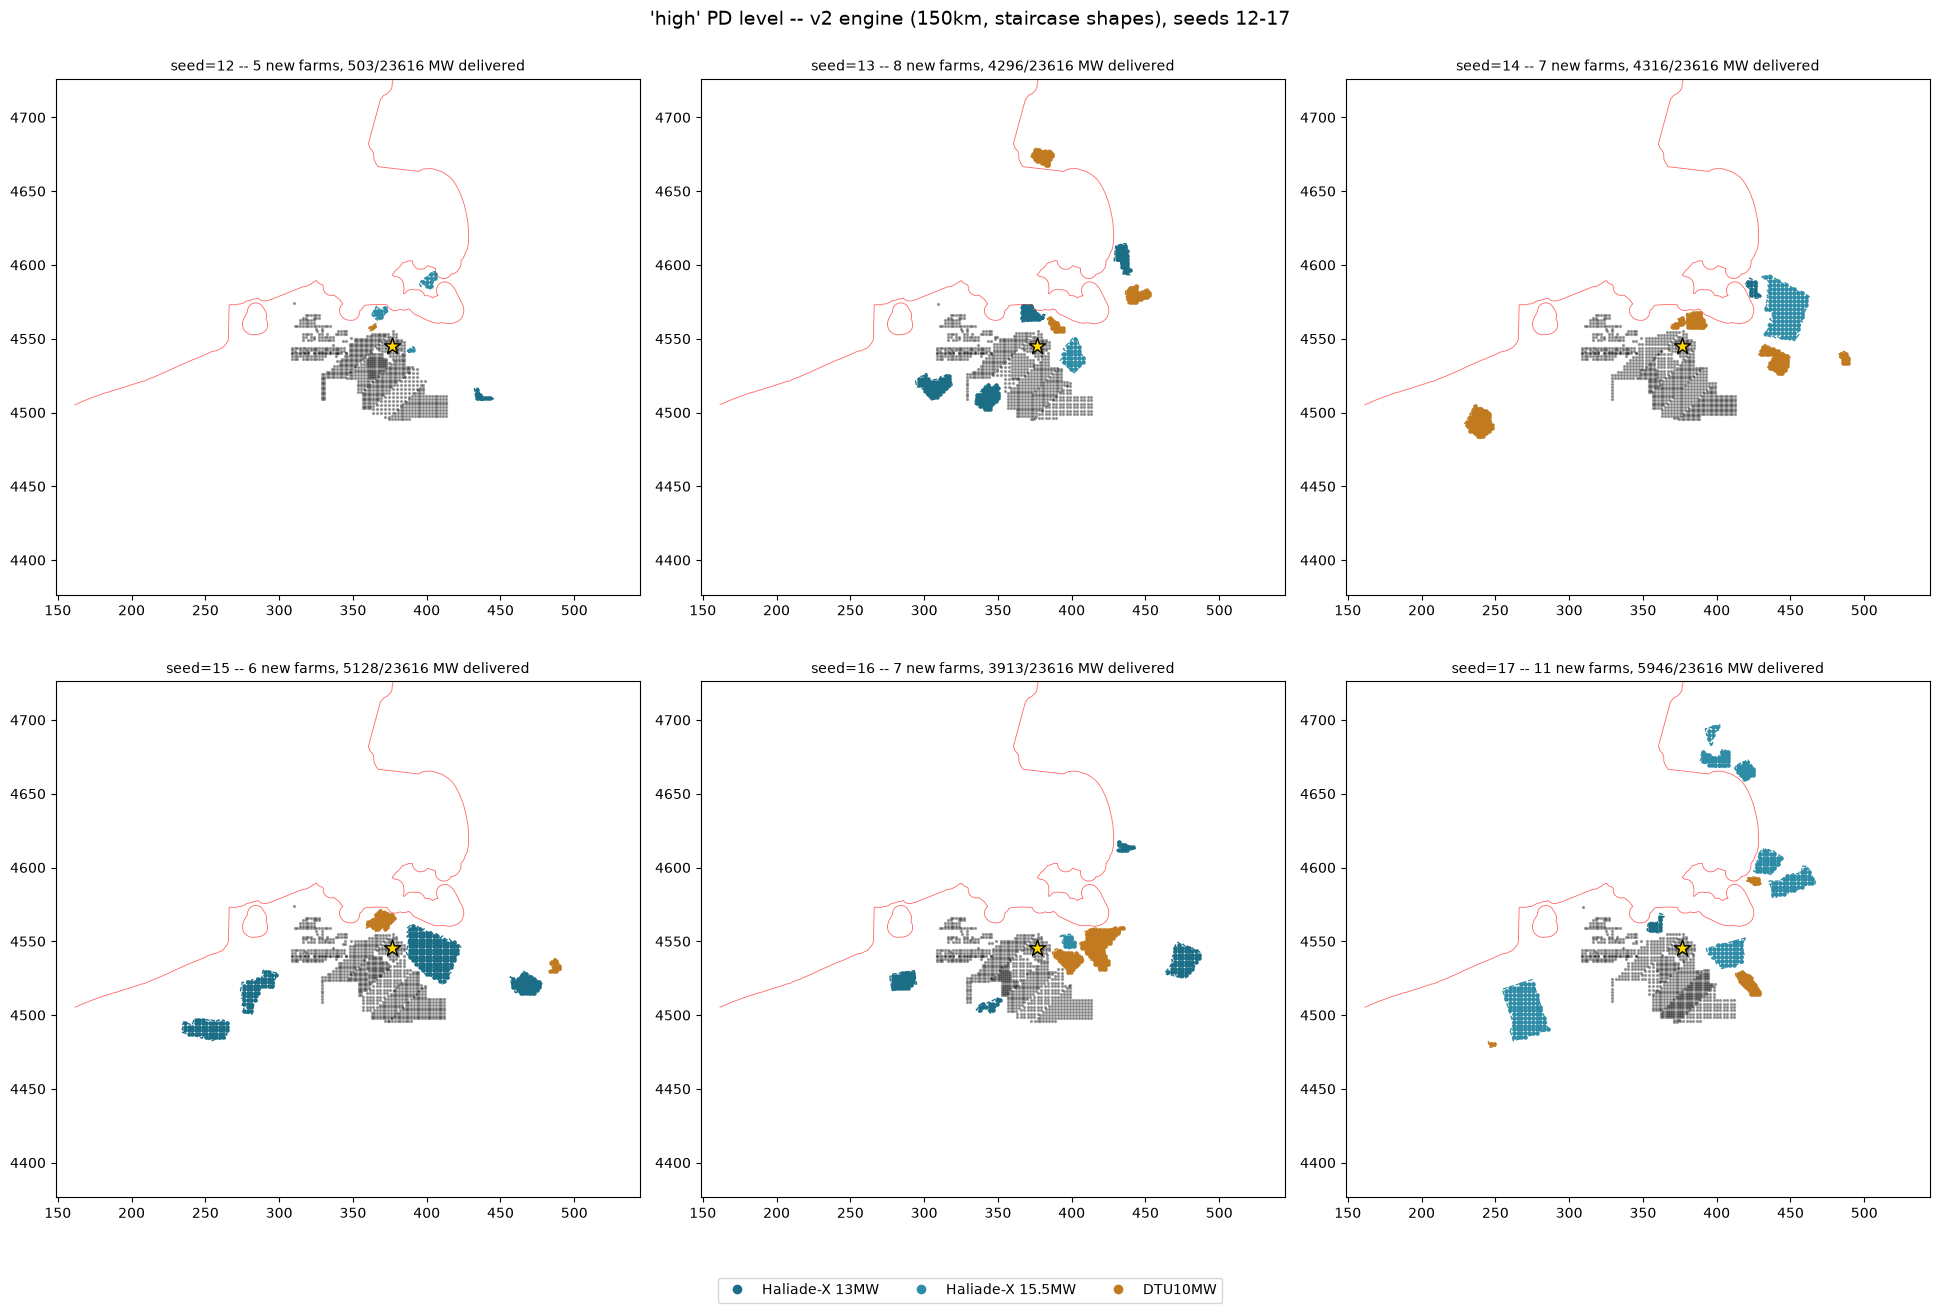

Saved: figures/v2_gallery_seeds_12_17.png

Gallery figures: ['figures/v2_gallery_seeds_00_05.png', 'figures/v2_gallery_seeds_06_11.png', 'figures/v2_gallery_seeds_12_17.png']


In [12]:
def plot_scenario_gallery(seeds, target_level, out_name, ncols=3, nrows=2):
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 6.5 * nrows))
    REAL_X_ALL = np.concatenate(REAL_FARM_X)
    REAL_Y_ALL = np.concatenate(REAL_FARM_Y)
    XLIM = ((REAL_X_ALL.min() - 160_000) / 1000, (REAL_X_ALL.max() + 160_000) / 1000)
    YLIM = ((REAL_Y_ALL.min() - 160_000) / 1000, (REAL_Y_ALL.max() + 160_000) / 1000)

    for ax, seed in zip(axes.flat, seeds):
        rows = []
        cx, cy, scenario = populate_scenario(target_level, np.random.default_rng(seed), log_rows=rows)
        for line in sla_lines_utm:
            ax.plot(line[:, 0] / 1000, line[:, 1] / 1000, color="red", linewidth=0.6, alpha=0.6)
        ax.scatter(cx / 1000, cy / 1000, s=2, color="black", alpha=0.3)
        req = sum(r["target_mw"] for r in rows)
        deliv = sum(r["delivered_mw"] for r in rows)
        for f in scenario:
            c = COLORS.get(f["turbine"], "gray")
            bx, by = f["shape"].exterior.xy
            ax.plot(np.array(bx) / 1000, np.array(by) / 1000, "--", color=c, linewidth=0.9)
            ax.scatter(f["pts"][:, 0] / 1000, f["pts"][:, 1] / 1000, s=5, color=c)
        ax.scatter(*(VINEYARD_CENTER / 1000), marker="*", s=150, color="gold", edgecolor="black", zorder=5)
        ax.set_xlim(*XLIM)
        ax.set_ylim(*YLIM)
        ax.set_aspect("equal")
        ax.set_title(f"seed={seed} -- {len(scenario)} new farms, {deliv:.0f}/{req:.0f} MW delivered", fontsize=10)

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=8, label=name)
               for name, c in COLORS.items()]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=10)
    fig.suptitle(f"'{target_level}' PD level -- v2 engine (150km, staircase shapes), seeds {seeds[0]}-{seeds[-1]}", fontsize=14)
    fig.tight_layout(rect=[0, 0.02, 1, 1])
    out_path = FIGURES_DIR / f"{out_name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")
    return out_path


gallery_paths = []
gallery_paths.append(plot_scenario_gallery(range(0, 6), "high", "v2_gallery_seeds_00_05"))
gallery_paths.append(plot_scenario_gallery(range(6, 12), "high", "v2_gallery_seeds_06_11"))
gallery_paths.append(plot_scenario_gallery(range(12, 18), "high", "v2_gallery_seeds_12_17"))
print("\nGallery figures:", [str(p) for p in gallery_paths])